# Preprocessing dan Ekstraksi Fitur

## Preprocessing: Penanganan Missing Value, Outliers dan Interpolasi

Pada tahap _Data Understanding_, kita telah mengidentifikasi adanya _missing values_ dan _outliers_. Untuk menangani masalah ini dan mempersiapkan data agar bisa diekstrak fiturnya secara berkesinambungan, kita menerapkan pembersihan data menggunakan metode Rentang Interkuartil (IQR) dan mengisi kekosongan data menggunakan **interpolasi linier**.

### Deteksi Missing Value

Deteksi _missing value_ (data kosong atau hilang) bertujuan untuk mengidentifikasi seberapa banyak data yang tidak terekam dalam observasi. Mengetahui jumlah dan persentase kekosongan data sangat penting sebelum dilakukan proses penanganan (seperti interpolasi), agar kita dapat mengukur kualitas dataset secara keseluruhan.

```python
import pandas as pd

df = pd.read_csv("nama_file_polutan.csv")

missing_value = df['nama_kolom_polutan'].isna().sum()
total_data = len(df)
persentase_missing = (missing_value / total_data) * 100

print(f"Jumlah missing value: {missing_value}")
print(f"Total data: {total_data}")
print(f"Persentase data missing: {persentase_missing:.2f}%")
```

1. NO2

In [1]:
import pandas as pd

df = pd.read_csv("./source/ekstraksi_fitur/NO2_Bangkalan_Terkini.csv")

missing_value = df['NO2'].isna().sum()
total_data = len(df)
persentase_missing = (missing_value / total_data) * 100

print(f"Jumlah missing value: {missing_value}")
print(f"Total data: {total_data}")
print(f"Persentase data missing: {persentase_missing:.2f}%")

Jumlah missing value: 30
Total data: 365
Persentase data missing: 8.22%


2. CO

In [2]:
import pandas as pd

df = pd.read_csv("./source/ekstraksi_fitur/CO_Bangkalan_Terkini.csv")

missing_value = df['CO'].isna().sum()
total_data = len(df)
persentase_missing = (missing_value / total_data) * 100

print(f"Jumlah missing value: {missing_value}")
print(f"Total data: {total_data}")
print(f"Persentase data missing: {persentase_missing:.2f}%")

Jumlah missing value: 34
Total data: 365
Persentase data missing: 9.32%


3. SO2

In [3]:
import pandas as pd

df = pd.read_csv("./source/ekstraksi_fitur/SO2_Bangkalan_Terkini.csv")

missing_value = df['SO2'].isna().sum()
total_data = len(df)
persentase_missing = (missing_value / total_data) * 100

print(f"Jumlah missing value: {missing_value}")
print(f"Total data: {total_data}")
print(f"Persentase data missing: {persentase_missing:.2f}%")

Jumlah missing value: 23
Total data: 365
Persentase data missing: 6.30%


### Deteksi dan Visualisasi Outlier (Metode IQR)

Metode _Interquartile Range_ (IQR) digunakan untuk mengidentifikasi nilai-nilai yang menyimpang atau berada di luar batas kewajaran. Data polutan yang nilainya lebih rendah dari _lower bound_ atau lebih tinggi dari _upper bound_ diklasifikasikan sebagai outlier.

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("nama_file_polutan.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Hitung IQR
Q1 = df['nama_kolom_polutan'].quantile(0.25)
Q3 = df['nama_kolom_polutan'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['nama_kolom_polutan'] < lower_bound) | (df['nama_kolom_polutan'] > upper_bound)]

print("Jumlah Outlier (IQR):", len(outliers_iqr))
print(outliers_iqr[['date', 'nama_kolom_polutan']].head())
```

1. NO2

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("./source/ekstraksi_fitur/NO2_Bangkalan_Terkini.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Hitung IQR
Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['NO2'] < lower_bound) | (df['NO2'] > upper_bound)]

print("Jumlah Outlier (IQR):", len(outliers_iqr))
print(outliers_iqr[['date', 'NO2']].head())

Jumlah Outlier (IQR): 3
         date       NO2
87 2025-11-26  0.000082
88 2025-11-27  0.000076
89 2025-11-28  0.000071


2. CO

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("./source/ekstraksi_fitur/CO_Bangkalan_Terkini.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Hitung IQR
Q1 = df['CO'].quantile(0.25)
Q3 = df['CO'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['CO'] < lower_bound) | (df['CO'] > upper_bound)]

print("Jumlah Outlier (IQR):", len(outliers_iqr))
print(outliers_iqr[['date', 'CO']].head())

Jumlah Outlier (IQR): 11
          date        CO
9   2025-09-09  0.018195
23  2025-09-23  0.036034
37  2025-10-07  0.044585
38  2025-10-08  0.038909
190 2026-03-09  0.036642


3. SO2

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("./source/ekstraksi_fitur/SO2_Bangkalan_Terkini.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Hitung IQR
Q1 = df['SO2'].quantile(0.25)
Q3 = df['SO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['SO2'] < lower_bound) | (df['SO2'] > upper_bound)]

print("Jumlah Outlier (IQR):", len(outliers_iqr))
print(outliers_iqr[['date', 'SO2']].head())

Jumlah Outlier (IQR): 8
          date       SO2
11  2025-09-11 -0.000963
219 2026-04-07  0.000801
293 2026-06-20  0.000714
311 2026-07-08  0.000691
343 2026-08-09  0.000739


Visualisasi batas ambang IQR terhadap distribusi data untuk melihat outlier secara lebih jelas:

```python
:tags: [hide-input]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("nama_file_polutan.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Hitung IQR
Q1 = df['nama_kolom_polutan'].quantile(0.25)
Q3 = df['nama_kolom_polutan'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df['nama_kolom_polutan'] < lower_bound) | (df['nama_kolom_polutan'] > upper_bound)]

plt.figure(figsize=(15,5))
plt.plot(df['date'], df['nama_kolom_polutan'], label="nama_kolom_polutan", linewidth=1)

plt.scatter(outliers_iqr['date'], outliers_iqr['nama_kolom_polutan'],
            color='red', marker='o', label="Outliers")

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data nama_kolom_polutan (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar nama_kolom_polutan")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()
```

1. NO2

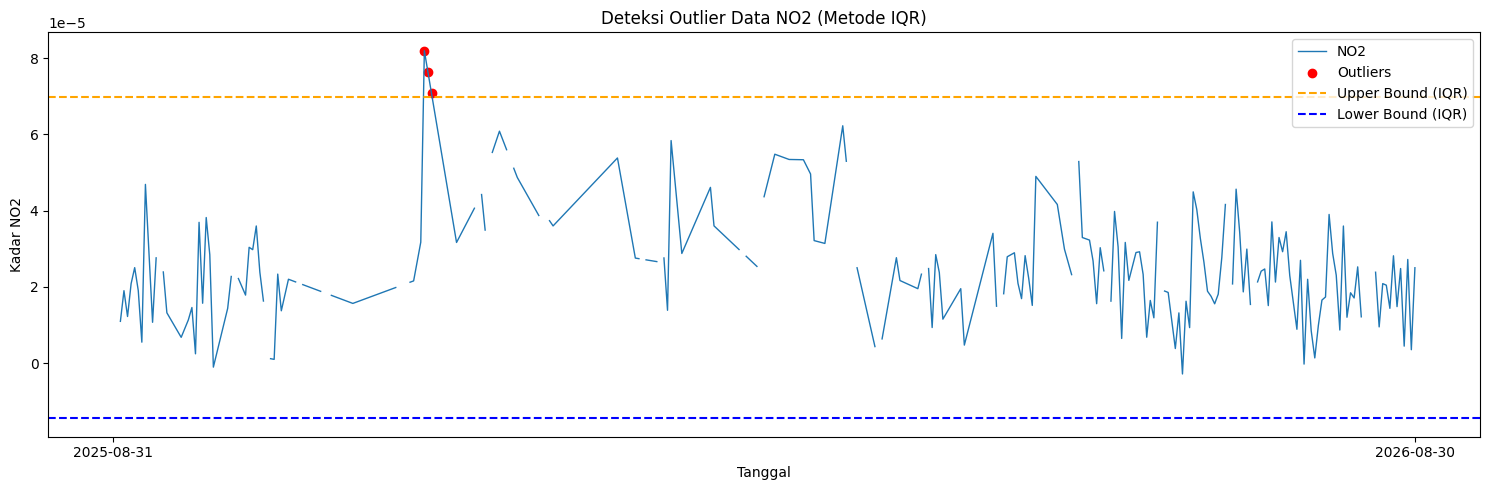

In [7]:
df = pd.read_csv("./source/ekstraksi_fitur/NO2_Bangkalan_Terkini.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Hitung IQR
Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df['NO2'] < lower_bound) | (df['NO2'] > upper_bound)]

plt.figure(figsize=(15,5))
plt.plot(df['date'], df['NO2'], label="NO2", linewidth=1)

plt.scatter(outliers_iqr['date'], outliers_iqr['NO2'],
            color='red', marker='o', label="Outliers")

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data NO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

2. CO

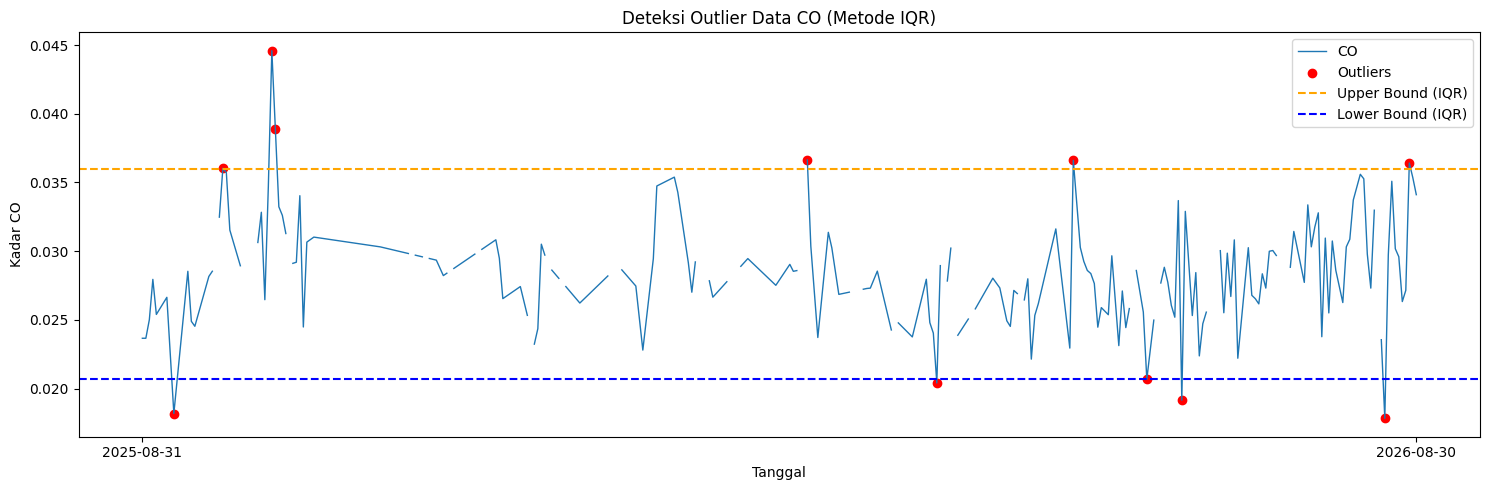

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("./source/ekstraksi_fitur/CO_Bangkalan_Terkini.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Hitung IQR
Q1 = df['CO'].quantile(0.25)
Q3 = df['CO'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df['CO'] < lower_bound) | (df['CO'] > upper_bound)]

plt.figure(figsize=(15,5))
plt.plot(df['date'], df['CO'], label="CO", linewidth=1)

plt.scatter(outliers_iqr['date'], outliers_iqr['CO'],
            color='red', marker='o', label="Outliers")

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data CO (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar CO")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

3. SO2

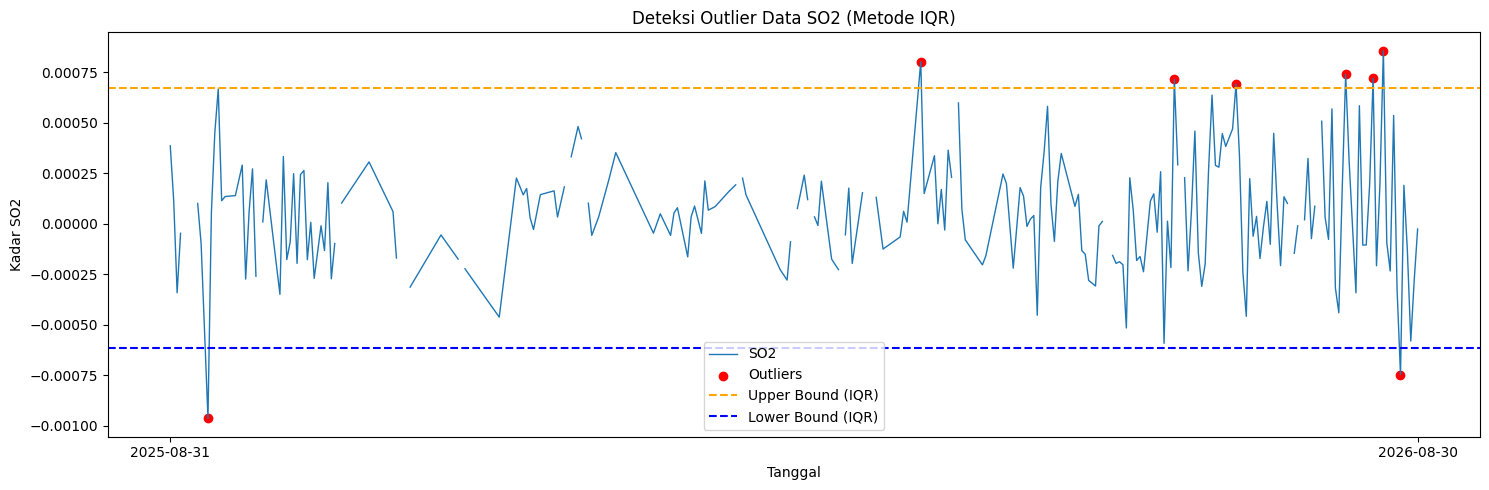

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("./source/ekstraksi_fitur/SO2_Bangkalan_Terkini.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Hitung IQR
Q1 = df['SO2'].quantile(0.25)
Q3 = df['SO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df['SO2'] < lower_bound) | (df['SO2'] > upper_bound)]

plt.figure(figsize=(15,5))
plt.plot(df['date'], df['SO2'], label="SO2", linewidth=1)

plt.scatter(outliers_iqr['date'], outliers_iqr['SO2'],
            color='red', marker='o', label="Outliers")

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data SO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar SO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

### Penanganan Outlier, Melengkapi Tanggal, dan Interpolasi Data

Setelah mendeteksi keberadaan outlier, langkah selanjutnya adalah menandainya sebagai nilai kosong (`NaN`). Karena pada data deret waktu terdapat banyak tanggal yang terlewat, kita melengkapi rentang waktunya (dari tanggal terawal hingga terakhir). Kemudian, metode interpolasi linier diterapkan pada keseluruhan dataset untuk mengisi nilai kosong (`NaN`) tersebut. Di akhir proses, teknik _backward fill_ (`bfill`) serta _forward fill_ (`ffill`) dimanfaatkan guna mengatasi nilai kosong pada bagian pinggir atau awalan dan akhiran rangkaian data yang tidak bisa diinterpolasi linier.

```python
# Tandai outlier menjadi NaN
df['polutan_cleaned'] = df['polutan'].mask(
    (df['polutan'] < lower_bound) | (df['polutan'] > upper_bound)
)

# Memasukkan data ke dalam rentang tanggal yang lengkap
df = df.set_index('date')
rentang_tanggal_lengkap = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
df_lengkap = df.reindex(rentang_tanggal_lengkap)

# interpolasi linier pada NaN yang sudah dibuat (dari outlier & reindex)
df_lengkap['polutan_filled'] = df_lengkap['polutan_cleaned'].interpolate(method='linear')
df_lengkap['polutan_filled'] = df_lengkap['polutan_filled'].bfill().ffill()

# Kembalikan index menjadi kolom
df_lengkap.index.name = 'date'
df_lengkap.reset_index(inplace=True)

# Simpan data yang telah dibersihkan dan diinterpolasi ke file CSV baru
df_polutan_Kwanyar = pd.DataFrame({
    "date": df_lengkap['date'],
    "polutan": df_lengkap['polutan_filled']
})
df_polutan_Kwanyar.to_csv("nama_hasil_file_polutan_cleaned.csv", index=False)
```

Grafik setelah penanganan Outlier dan Penambahan Tanggal

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("nama_file_polutan_final.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Hitung IQR
Q1 = df['nama_kolom_polutan'].quantile(0.25)
Q3 = df['nama_kolom_polutan'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['nama_kolom_polutan'] < lower_bound) | (df['nama_kolom_polutan'] > upper_bound)]

print("Jumlah Outlier (IQR):", len(outliers_iqr))
print(outliers_iqr[['date', 'nama_kolom_polutan']].head())
```

1. NO2

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("./source/ekstraksi_fitur/NO2_Bangkalan_final.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Hitung IQR
Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['NO2'] < lower_bound) | (df['NO2'] > upper_bound)]

print("Jumlah Outlier (IQR):", len(outliers_iqr))
print(outliers_iqr[['date', 'NO2']].head())

Jumlah Outlier (IQR): 0
Empty DataFrame
Columns: [date, NO2]
Index: []


2. CO

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("./source/ekstraksi_fitur/CO_Bangkalan_final.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Hitung IQR
Q1 = df['CO'].quantile(0.25)
Q3 = df['CO'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['CO'] < lower_bound) | (df['CO'] > upper_bound)]

print("Jumlah Outlier (IQR):", len(outliers_iqr))
print(outliers_iqr[['date', 'CO']].head())

Jumlah Outlier (IQR): 0
Empty DataFrame
Columns: [date, CO]
Index: []


3. SO2

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("./source/ekstraksi_fitur/SO2_Bangkalan_final.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Hitung IQR
Q1 = df['SO2'].quantile(0.25)
Q3 = df['SO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['SO2'] < lower_bound) | (df['SO2'] > upper_bound)]

print("Jumlah Outlier (IQR):", len(outliers_iqr))
print(outliers_iqr[['date', 'SO2']].head())

Jumlah Outlier (IQR): 0
Empty DataFrame
Columns: [date, SO2]
Index: []


Visualisasi batas ambang IQR terhadap distribusi data untuk melihat outlier secara lebih jelas:

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("nama_file_polutan_final.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Hitung IQR
Q1 = df['nama_kolom_polutan'].quantile(0.25)
Q3 = df['nama_kolom_polutan'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df['nama_kolom_polutan'] < lower_bound) | (df['nama_kolom_polutan'] > upper_bound)]

plt.figure(figsize=(15,5))
plt.plot(df['date'], df['nama_kolom_polutan'], label="nama_kolom_polutan", linewidth=1)

plt.scatter(outliers_iqr['date'], outliers_iqr['nama_kolom_polutan'],
            color='red', marker='o', label="Outliers")

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data nama_kolom_polutan (Metode IQR) - Setelah Penanganan")
plt.xlabel("Tanggal")
plt.ylabel("Kadar nama_kolom_polutan")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()
```

1. NO2

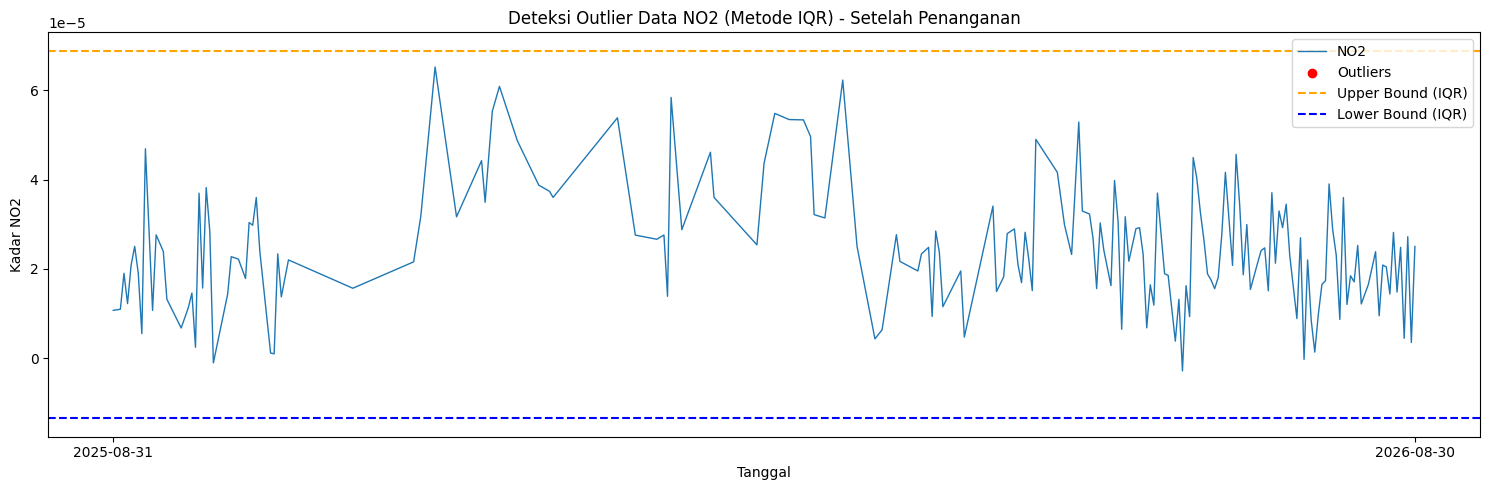

In [13]:
df = pd.read_csv("./source/ekstraksi_fitur/NO2_Bangkalan_final.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Hitung IQR
Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df['NO2'] < lower_bound) | (df['NO2'] > upper_bound)]

plt.figure(figsize=(15,5))
plt.plot(df['date'], df['NO2'], label="NO2", linewidth=1)

plt.scatter(outliers_iqr['date'], outliers_iqr['NO2'],
            color='red', marker='o', label="Outliers")

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data NO2 (Metode IQR) - Setelah Penanganan")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

2. CO

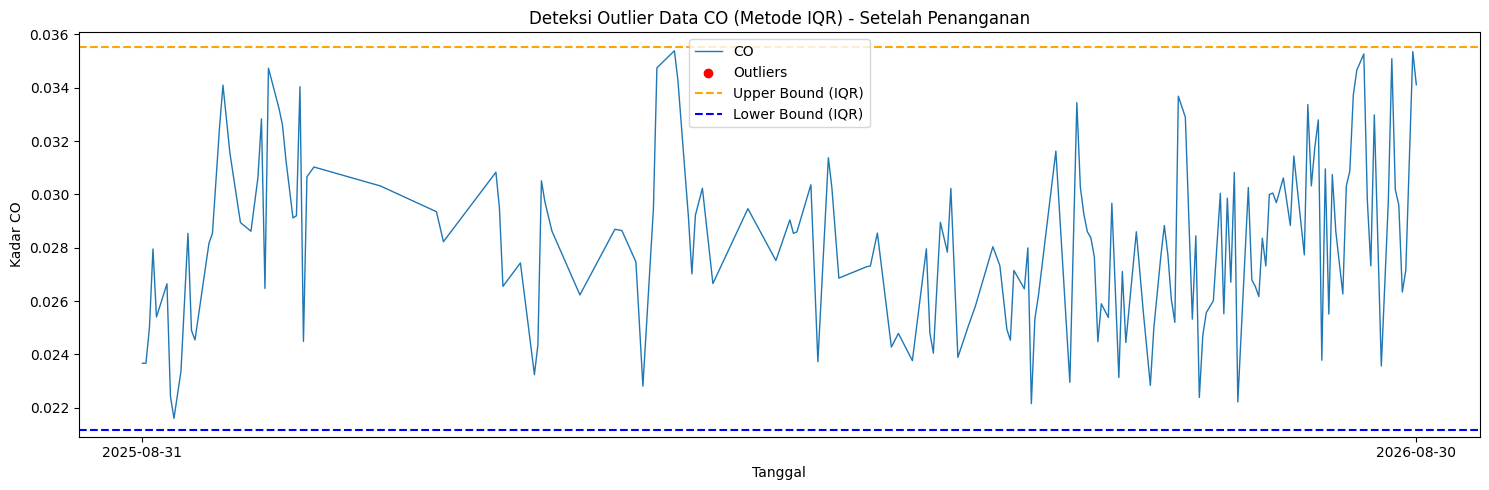

In [14]:
df = pd.read_csv("./source/ekstraksi_fitur/CO_Bangkalan_final.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Hitung IQR
Q1 = df['CO'].quantile(0.25)
Q3 = df['CO'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df['CO'] < lower_bound) | (df['CO'] > upper_bound)]

plt.figure(figsize=(15,5))
plt.plot(df['date'], df['CO'], label="CO", linewidth=1)

plt.scatter(outliers_iqr['date'], outliers_iqr['CO'],
            color='red', marker='o', label="Outliers")

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data CO (Metode IQR) - Setelah Penanganan")
plt.xlabel("Tanggal")
plt.ylabel("Kadar CO")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

3. SO2

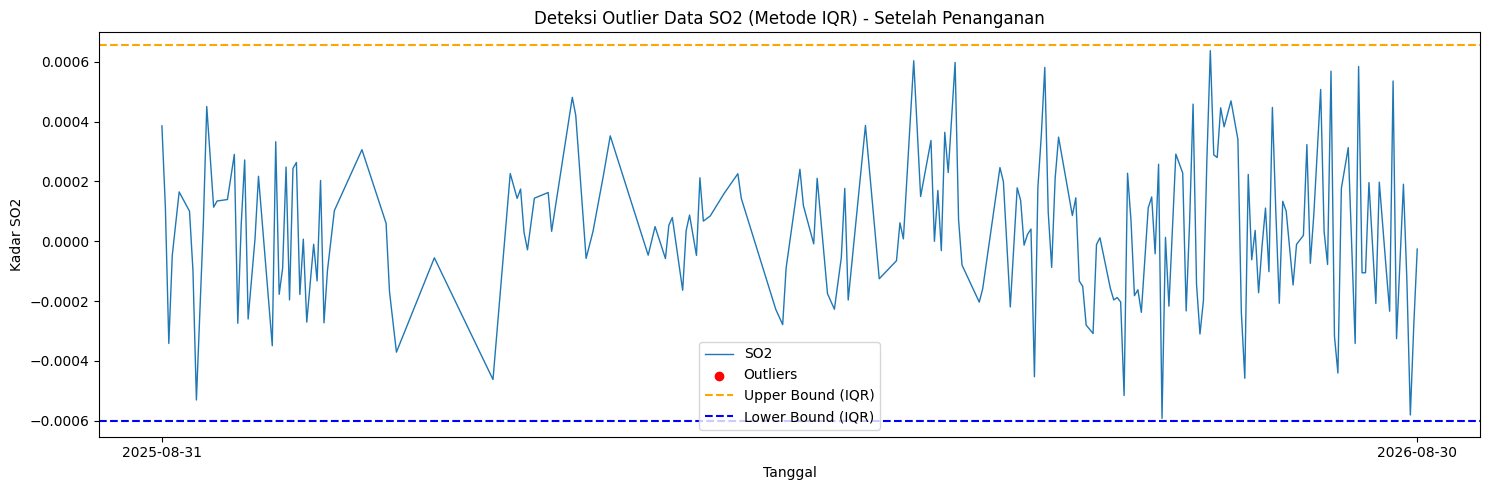

In [15]:
df = pd.read_csv("./source/ekstraksi_fitur/SO2_Bangkalan_final.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Hitung IQR
Q1 = df['SO2'].quantile(0.25)
Q3 = df['SO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df['SO2'] < lower_bound) | (df['SO2'] > upper_bound)]

plt.figure(figsize=(15,5))
plt.plot(df['date'], df['SO2'], label="SO2", linewidth=1)

plt.scatter(outliers_iqr['date'], outliers_iqr['SO2'],
            color='red', marker='o', label="Outliers")

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data SO2 (Metode IQR) - Setelah Penanganan")
plt.xlabel("Tanggal")
plt.ylabel("Kadar SO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

## Ekstraksi Fitur Deret Waktu (Time Series)

Dengan data deret waktu polutan udara yang konsisten (tanpa tanggal hilang dan tanpa _outlier_), kita dapat melangkah ke ekstraksi berbagai fitur statistik, temporal, maupun spektral. Fitur-fitur ini sangat berguna sebagai parameter *input* yang merepresentasikan karakteristik *trend* harian polutan ke dalam model _machine learning_ maupun _deep learning_.

Kita akan memanfaatkan modul pustaka Python bernama `tsfel` (_Time Series Feature Extraction Library_) guna mempermudah proses komputasi serta standarisasi ragam tipe fitur.

Berikut adalah sintaks kode implementasi untuk mengekstraksi sebanyak 68 fitur otomatis pada deret data NO₂ (dan berlaku perlakuan serupa untuk unsur polutan lainnya):

```python
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

# ---------- 1. Muat data yang sudah dibersihkan ----------
df = pd.read_csv('nama_file_polutan_cleaned.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

target_pollutant = 'nama_polutan'

# Pastikan data di-casting ke tipe numerik.
df[target_pollutant] = pd.to_numeric(df[target_pollutant], errors='coerce')

# Interpolasi terakhir untuk berjaga-jaga apabila terdapat sisa format nan
df_clean = df.set_index('date').interpolate(method='time').ffill().bfill()
fs = 1
signal_1d = df_clean[target_pollutant].astype(float).values

# ---------- 2. Inisiasi 68 Daftar Fitur TSFEL ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))

# ---------- 3. Fungsi ekstraksi dan penyeragaman output  ----------

# Fungsi bantuan (helper) merubah output multivariat TSFEL menjadi float tunggal/skalar
def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)

# Fungsi map pemanggilan fungsi TSFEL 
def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)

# Lakukan ekstraksi iteratif pada fitur
row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])

print(f"Berhasil! Jumlah fitur yang diekstrak pada {target_pollutant}: {extracted_features_final.shape[1]}")

# Export hasil ke file CSV
extracted_features_final.to_csv(f'nama_hasil_ekstraksi_fitur_TSFEL.csv', index=False)
```

Data hasil ekstraksi fitur menggunakan TSFEL

1. NO2

In [16]:
df = pd.read_csv("./source/Ekstraksi_fitur/NO2_Kwanyar_TSFEL.csv")
df.head(5)

,abs_energy,auc,autocorr,average_power,calc_centroid,calc_max,calc_mean,calc_median,calc_min,calc_std,...,spectral_spread,spectral_variation,spectrogram_mean_coeff,sum_abs_diff,wavelet_abs_mean,wavelet_energy,wavelet_entropy,wavelet_std,wavelet_var,zero_cross
0,3.561887e-07,0.010139,13.0,9.785405e-10,173.038786,0.000065,0.000028,0.000026,-0.000003,0.000014,...,0.15309,0.262819,2.946177e-10,0.002209,0.000001,0.000018,2.126274,0.000018,3.696060e-10,6.0


2. CO

In [17]:
df = pd.read_csv("./source/Ekstraksi_fitur/CO_Kwanyar_TSFEL.csv")
df.head(5)

,abs_energy,auc,autocorr,average_power,calc_centroid,calc_max,calc_mean,calc_median,calc_min,calc_std,...,spectral_spread,spectral_variation,spectrogram_mean_coeff,sum_abs_diff,wavelet_abs_mean,wavelet_energy,wavelet_entropy,wavelet_std,wavelet_var,zero_cross
0,0.295985,10.316484,3.0,0.000813,180.354669,0.035389,0.028343,0.028357,0.021601,0.00275,...,0.126886,0.593124,0.000012,0.490562,0.001608,0.0067,2.122624,0.00648,0.000048,0.0


3. SO2

In [18]:
df = pd.read_csv("./source/Ekstraksi_fitur/SO2_Kwanyar_TSFEL.csv")
df.head(5)

,abs_energy,auc,autocorr,average_power,calc_centroid,calc_max,calc_mean,calc_median,calc_min,calc_std,...,spectral_spread,spectral_variation,spectrogram_mean_coeff,sum_abs_diff,wavelet_abs_mean,wavelet_energy,wavelet_entropy,wavelet_std,wavelet_var,zero_cross
0,0.000019,0.058176,2.0,5.198692e-08,201.287422,0.000637,0.000033,0.000036,-0.000592,0.000225,...,0.146254,0.154005,8.342241e-08,0.055033,0.000001,0.000328,2.154088,0.000328,1.141906e-07,103.0
